# Uczenie reprezentacji wielokanałowego EEG do klasyfikacji choroby Alzheimera

| Osoba | Wkład |
|---|---|
| **Filip** | Potok danych (preprocessing, czyszczenie, cięcie EEG), infrastruktura repozytorium (DVC), baseline (Autoenkoder) |
| **Damian** | Definicja, adaptacja i trening dwóch modeli kontrastywnych (TNC, CPC) + klasyfikacja liniowa |
| **Jakub** | Model przestrzeni stanów Mamba, ewaluacja końcowa, badanie hiperparametrów struktur sieciowych |

---
# 1. Opis problemu

### 1.1. Dane wejściowe
Wielokanałowe sygnały **EEG** ze zbioru **BrainLat**. Surowe nagrania (EEGLAB `.set`) są cięte na **okna 3-sekundowe** i zapisywane jako tensory PyTorch - jeden plik na pacjenta, kształt `(liczba_okien, 128 kanałów, 1536 próbek)`. Okna zachowują **kolejność czasową**, co jest kluczowe dla metod kontrastywnych wykorzystujących strukturę czasu.

### 1.2. Dane wyjściowe
Binarna etykieta diagnozy: **AD** (Alzheimer, `1`) vs **CN** (grupa kontrolna, `0`). Zbiór: **67 pacjentów** (32 CN, 35 AD).

### 1.3. Typ problemu
**Klasyfikacja binarna.** Reprezentacje uczone są **bez etykiet** (samonadzorowanie); etykiety wchodzą dopiero na etapie *klasyfikacji liniowej* (linear evaluation).

### 1.4. Hipoteza badawcza
> Reprezentacje wyuczone metodami kontrastywnymi (TNC, CPC), wykorzystującymi **strukturę czasową** EEG, dadzą cechy lepiej rozdzielające klasy AD/CN niż naiwny baseline (Autoenkoder rekonstrukcyjny) - mierzone wyższym **ROC-AUC** w klasyfikacji liniowej.

### 1.5. Czym jest "klasyfikacja liniowa" (linear evaluation)
Standardowy protokół oceny reprezentacji w uczeniu samonadzorowanym:
1. enkoder uczy się **bez etykiet**;
2. enkoder jest **zamrażany** (wagi nie zmieniają się);
3. na zamrożonych cechach trenujemy **wyłącznie prosty klasyfikator** (liniowy / płytka głowica);
4. mierzymy AUC/accuracy.

Jeśli słaby klasyfikator liniowy potrafi rozdzielić klasy na danych cechach, to znaczy, że **enkoder nauczył się użytecznej, liniowo separowalnej reprezentacji**. Liniowość izoluje wkład samego enkodera.

---
# 2. Dane: wczytanie, preprocessing, przygotowanie

Cały potok przetwarzania danych jest zaimplementowany w `src/data/make_dataset.py` (klasa `BrainLatProcessor`) i wpięty jako etap **`preprocess`** w pipeline DVC (`dvc.yaml`). Notebook **nie wykonuje** preprocessingu - korzysta z gotowych, wersjonowanych przez DVC tensorów w `data/processed/*.pt`. Poniżej opis kroków odtworzony ze skryptu.

### 2.1. Źródło i charakterystyka zbioru BrainLat
- **Zbiór:** BrainLat - wielokanałowe EEG spoczynkowe, surowe nagrania w formacie EEGLAB (`.set`), wczytywane biblioteką **MNE** (`mne.io.read_raw_eeglab`).
- **Pacjenci:** 67 (po preprocessingu: **32 CN** + **35 AD**). Etykiety czytane z metadanych (`metadata/Records_AD_EEG_data.csv`, `Records_HC_EEG_data.csv`): **AD = 1**, **CN/HC = 0**.
- **Kanały:** 128. **Częstotliwość próbkowania:** 512 Hz (wynika z kształtu okna: 1536 próbek / 3 s).

### 2.2. Kroki preprocessingu (`make_dataset.py`)
1. **Wczytanie + dopasowanie etykiet.** Dla każdego pacjenta z metadanych szukany jest pasujący plik `.set` (po prefiksie `id_EEG`); brakujące/niepasujące rekordy są pomijane z komunikatem.
2. **Filtracja częstotliwościowa.** Filtr pasmowo-przepustowy **0.5-45 Hz** (FIR, `fir_design='firwin'`) - usuwa dryf wolnozmienny (<0.5 Hz) i pasmo sieciowe / wysokoczęstotliwościowy szum (>45 Hz). *Uwaga:* skrypt nie stosuje automatycznego usuwania artefaktów (ICA itp.) - czyszczenie ogranicza się do filtracji pasmowej.
3. **Cięcie na okna.** Sygnał dzielony jest na nienachodzące okna o długości `window_size = 3.0 s` (= `3.0 × sfreq` próbek). Końcówka krótsza niż pełne okno jest obcinana; pacjenci ze zbyt krótkim sygnałem są pomijani.
4. **Normalizacja per-okno, per-kanał.** Każde okno i każdy kanał normalizowane są osobno do **z-score** w obrębie własnych próbek: `(x − mean) / (std + 1e-8)` (statystyki liczone po osi czasu). Skaluje to amplitudy między pacjentami i kanałami do wspólnego zakresu.
5. **Zapis.** Tensor pacjenta o kształcie `(num_windows, 128, 1536)` zapisywany jest jako `data/processed/{id}_{diagnosis}_label_{0|1}.pt`. Etykieta i identyfikator pacjenta są zakodowane w nazwie pliku (odczytywane potem przez dataloadery).

### 2.3. Podział danych
Podział na foldy realizuje `src/data/dataloaders.py` (`StratifiedGroupKFold`, **grupa = pacjent**): wszystkie okna jednego pacjenta trafiają w całości do treningu **albo** walidacji, nigdy do obu. Podział jest **deterministyczny i współdzielony** przez wszystkie modele (AE / TNC / CPC / Mamba), dzięki czemu porównanie metod odbywa się na identycznych foldach. Stratyfikacja zachowuje proporcje klas AD/CN w każdym foldzie. Szczegóły walidacji krzyżowej - w sekcji 3.1 (komórka "Metryki, walidacja i funkcje wspólne").

In [78]:
# Preprocessing NIE jest wykonywany w notebooku - realizuje go etap DVC `preprocess`
# (src/data/make_dataset.py), a wynik (data/processed/*.pt) jest wersjonowany przez DVC.
# Ponizej tylko PODGLAD parametrow potoku z params.yaml (zrodlo prawdy dla `dvc repro`).
import os as _os, yaml as _yaml
_pp = _os.path.join('..', 'params.yaml')
_pp = _pp if _os.path.exists(_pp) else 'params.yaml'
with open(_pp, encoding='utf-8') as _f:
    _md = _yaml.safe_load(_f).get('make_dataset', {})
print('Parametry preprocessingu (params.yaml -> make_dataset):')
for _k, _v in _md.items():
    print(f'  {_k}: {_v}')
print('\nDane przetworzone: data/processed/*.pt  (jeden plik na pacjenta).')
print('Aby (prze)liczyc preprocessing: `dvc repro preprocess`.')

Parametry preprocessingu (params.yaml -> make_dataset):
  window_size: 3.0
  dataset_name: brainlat
  raw_dir: data/raw/brainlat
  processed_dir: data/processed

Dane przetworzone: data/processed/*.pt  (jeden plik na pacjenta).
Aby (prze)liczyc preprocessing: `dvc repro preprocess`.


---
# 3. Baseline - Autoenkoder

**Punkt odniesienia (naiwny baseline)** dla metod kontrastywnych z sekcji 4-6. Autoenkoder uczy się reprezentacji **rekonstrukcją** (bez wykorzystania struktury czasowej i bez etykiet), więc pokazuje, ile da się osiągnąć "naiwnie" - przed dodaniem sygnału kontrastywnego.

**Architektura** (`src/models/baseline_ae.py`): konwolucyjny autoenkoder 1D.
- **Enkoder:** `Conv1d(128→16, k=15) → BatchNorm → ReLU → MaxPool(2)` ×, następnie `Conv1d(16→32, k=11) → BatchNorm → ReLU → MaxPool(2)`. Reprezentacja = spłaszczona mapa cech ostatniej warstwy (rozmiar wyliczany dynamicznie).
- **Dekoder:** symetryczny - `Upsample(×2) → ConvTranspose1d` ×2, odtwarzający sygnał wejściowy.
- **Strata:** MSE rekonstrukcji (`reconstruction ≈ wejście`).

**Trening i ewaluacja: w pipeline, nie w notebooku.** Enkoder AE trenuje etap DVC **`train_repr`** (`src/training/train_representation.py`, 30 epok, Adam lr=1e-3, 5-fold), a klasyfikację liniową - etap **`train_classifier`**. Notebook (3.2) jedynie **wczytuje gotowe artefakty pipeline**:
- wyniki liczbowe → `notebooks/results/ae_default.json` (AUC/Acc per fold),
- wagi enkodera → `models/representations/ae/encoder_fold_*.pth` (śledzone przez DVC),
- głowice liniowe → `models/evaluation/ae/head_{win,pat}_fold_*.pth`.

Dzięki temu sekcja 3.2 nic nie trenuje - liczby pochodzą wprost z pipeline (spójne z `dvc repro`).

## 3.1. Konfiguracja, wczytanie danych i funkcje wspólne
*(współdzielone przez sekcje 3–5)*

In [79]:
import os, sys, glob, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Modele (do budowy enkoderow w model_factory) i dataloadery (do inspekcji danych nizej).
from src.models.cpc import CPCModel
from src.models.tnc import TNCModel
from src.models.mamba_model import MambaModel
from src.data.dataloaders import get_fold_sequence_dataloaders, get_fold_dataloaders
# Cala logika ewaluacji reprezentacji zyje w src/evaluation/ (jedno zrodlo prawdy, wspoldzielone
# ze skryptami CLI przez ssl_training). Notebook tylko ja wola - patrz cienkie wrappery w 3.1.
from src.evaluation.linear_evaluation import eval_n_folds  # run_cv_smart/run_cv_ae owinięte w 3.1
from src.evaluation.hp_search import top2, best_params_from  # hp_study/grid_search owinięte w 3.1
from src.evaluation.per_patient import PERWIN_FILE  # eval_per_patient owinięte w 3.1
from src.evaluation.results_cache import load_json
from src.evaluation.reporting import fmt, plot_hist
from src.evaluation import visualization as _viz  # PCA reprezentacji + ROC per-pacjent (owiniete w 3.1)

DATA_DIR = os.path.join(ROOT, 'data', 'processed')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print('ROOT      :', ROOT)
print('Urzadzenie:', DEVICE)
print('Pliki .pt :', len(glob.glob(os.path.join(DATA_DIR, '*.pt'))))

ROOT      : e:\Realny dysk\II_stopien\1_sem\Uczenie_Reprezentacji\Laby\Alzheimer-classifier
Urzadzenie: cuda
Pliki .pt : 67


**Przełącznik trybu.** Trening na CPU jest wolny. `QUICK=True` → szybki przebieg do weryfikacji poprawności; `QUICK=False` → pełne wyniki do sprawozdania (najlepiej GPU).

**Zapisywanie / wczytywanie (dla współpracy i DVC).** Artefakty na dysku:
- **wagi enkoderów** → `models/representations/<wariant>/encoder_fold_*.pth` (→ DVC);
- **głowice liniowe** → `models/evaluation/<wariant>/head_{win,pat}_fold_*.pth` (→ DVC) - osobno dla metryki per-okno (`win`) i per-pacjent (`pat`);
- **wyniki liczbowe** (historie, tabele HP/CV, metryki) → `notebooks/results/*.{json,csv}` (→ git).

Wczytywanie steruje się **osobno dla każdego modelu i osobno dla dwóch etapów**:
- `*_LOAD_ENCODER` - wczytaj gotowe **wagi enkodera** zamiast trenować SSL (kontroluje też trening enkoderów w badaniu HP);
- `*_LOAD_PROBE` - nie trenuj głowicy: wczytaj gotowe wyniki (JSON) albo zapisaną **głowicę** i policz metryki samym inference.

Można więc wziąć gotowy enkoder z dysku, ale **przeliczyć ewaluację liniową od nowa** (`*_LOAD_ENCODER=True`, `*_LOAD_PROBE=False`). Gdy plików nie ma, dana część trenuje się od zera niezależnie od flagi.

**Early-stopping.** Każda ewaluacja liniowa (sekcje 4/5 oraz 7.1) przerywa trening głowicy, gdy AUC nie poprawia się przez `PROBE_PATIENCE` epok.

In [80]:
QUICK = False

AE_LOAD_ENCODER,  AE_LOAD_PROBE  = True, True
TNC_LOAD_ENCODER, TNC_LOAD_PROBE = True, True
CPC_LOAD_ENCODER, CPC_LOAD_PROBE = True, True
MAMBA_LOAD_ENCODER, MAMBA_LOAD_PROBE = True, True

if QUICK:
    N_SPLITS, SSL_EPOCHS, PROBE_EPOCHS = 2, 3, 10
    HP_SPLITS, SSL_EPOCHS_FINAL = 2, 3
    PROBE_PATIENCE = 3
else:
    N_SPLITS, SSL_EPOCHS, PROBE_EPOCHS = 5, 30, 30
    HP_SPLITS, SSL_EPOCHS_FINAL = 3, 40
    PROBE_PATIENCE = 5

RESULTS_DIR = os.path.join(ROOT, 'notebooks', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Tryb: {"SZYBKI" if QUICK else "PEŁNY"} | n_splits={N_SPLITS} hp_splits={HP_SPLITS} '
      f'ssl={SSL_EPOCHS} ssl_final={SSL_EPOCHS_FINAL} probe={PROBE_EPOCHS} patience={PROBE_PATIENCE}')
print(f'Wczytywanie (enkoder/probe):  AE=({AE_LOAD_ENCODER},{AE_LOAD_PROBE})  '
      f'TNC=({TNC_LOAD_ENCODER},{TNC_LOAD_PROBE})  CPC=({CPC_LOAD_ENCODER},{CPC_LOAD_PROBE})  '
      f'Mamba=({MAMBA_LOAD_ENCODER},{MAMBA_LOAD_PROBE})')

Tryb: PEŁNY | n_splits=5 hp_splits=3 ssl=30 ssl_final=40 probe=30 patience=5
Wczytywanie (enkoder/probe):  AE=(True,True)  TNC=(True,True)  CPC=(True,True)  Mamba=(True,True)


C:\Users\damia\AppData\Local\Temp\ipykernel_28572\477757102.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  n_per_patient = [torch.load(f).shape[0] for f in files]
C:\Us

Pacjentów: 67  (CN=32, AD=35)
Kształt pacjenta: (200, 128, 1536)  -> (okna, kanały, próbki)
Okien/pacjenta: min=47 max=225 śr=148
Fold 0: 53 train / 14 val pacjentów | leakage: 0 (musi być 0)


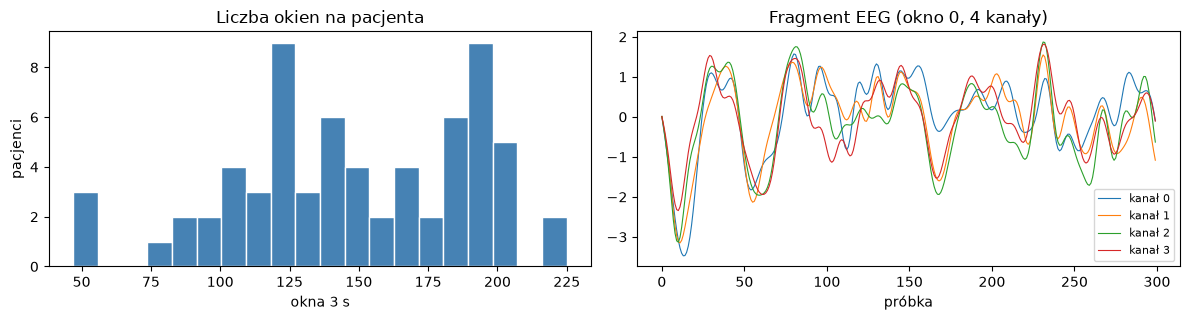

In [81]:
# --- Inspekcja danych: kształt, rozkład klas, brak przecieku pacjentów ---
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.pt')))
labels = [int(os.path.basename(f).split('_label_')[1].replace('.pt','')) for f in files]
n_per_patient = [torch.load(f).shape[0] for f in files]
ex = torch.load(files[0])

print(f'Pacjentów: {len(files)}  (CN={labels.count(0)}, AD={labels.count(1)})')
print(f'Kształt pacjenta: {tuple(ex.shape)}  -> (okna, kanały, próbki)')
print(f'Okien/pacjenta: min={min(n_per_patient)} max={max(n_per_patient)} śr={np.mean(n_per_patient):.0f}')

fold0, tl_seq, vl_seq = next(get_fold_sequence_dataloaders(DATA_DIR, n_splits=N_SPLITS))
leak = set(tl_seq.dataset.subjects) & set(vl_seq.dataset.subjects)
print(f'Fold 0: {len(tl_seq)} train / {len(vl_seq)} val pacjentów | leakage: {len(leak)} (musi być 0)')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
ax[0].hist(n_per_patient, bins=20, color='steelblue', edgecolor='white')
ax[0].set_title('Liczba okien na pacjenta')
ax[0].set_xlabel('okna 3 s')
ax[0].set_ylabel('pacjenci')

for ch in range(4):
    ax[1].plot(ex[0, ch, :300].numpy(), lw=0.8, label=f'kanał {ch}')
ax[1].set_title('Fragment EEG (okno 0, 4 kanały)')
ax[1].set_xlabel('próbka')
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Metryki, walidacja i funkcje wspólne

**Metryki:** **ROC-AUC** (wiodąca) i **Accuracy**, średnia ± std po foldach. Dodatkowo per-pacjent: **F1, Precision, Recall** dla klasy AD (sekcja 7.1).

**Walidacja krzyżowa (cała próba, bez osobnego test setu).** `StratifiedGroupKFold` (**5 foldów**) na **poziomie pacjenta**: żaden pacjent nie jest jednocześnie w treningu i walidacji (brak *data leakage*). Wynik = średnia z 5 foldów.
> Przy 67 pacjentach **nie** wydzielamy osobnego zbioru testowego - held-out test miałby ~13 osób (loteria), a tracilibyśmy dane treningowe. CV na całej próbie to standard dla małych zbiorów.

**Dobór hiperparametrów - dwa etapy o różnym koszcie.**
- **Badanie wpływu HP** (4.3 / 5.3) liczymy na **3 foldach** (`HP_SPLITS`) - pokazuje *trend* i wyłania 2 najlepsze wartości każdego parametru.
- **Siatka 2×2** (4.4 / 5.4) - finalny dobór - sprawdza 4 kombinacje (2 najlepsze wartości × 2 najlepsze) na **pełnym 5-fold CV**. Zastępuje random search: deterministyczna, tania, oparta na danych z badania HP.

**Finalny model `best`** trenowany z większą liczbą epok SSL (`SSL_EPOCHS_FINAL=40` vs `SSL_EPOCHS=30`) - finalny wariant zasługuje na dłuższy trening.

**Uwaga o uczciwości.** Siatka 2×2 i wariant „best" korzystają z tego samego CV, na którym raportujemy wynik → lekkie optymistyczne obciążenie „best". Pełna ścisłość wymagałaby *nested CV* (niepraktycznego przy tak małym zbiorze). „best" = orientacyjny sufit, „domyślny" = uczciwy wynik bez strojenia.

In [82]:
# Cienkie wrappery: cala logika ewaluacji jest w src/evaluation/ (zaimportowana wyzej).
# Tutaj tylko wstrzykujemy KONTEKST tego notebooka (sciezki, urzadzenie, early-stopping),
# zeby wywolania w sekcjach 3-7 byly krotkie. Funkcje z src/ przyjmuja kontekst argumentami
# (brak stanu globalnego) - te wrappery to jedyne miejsce, gdzie kontekst jest "zaszyty".
from src.evaluation import linear_evaluation as _le
from src.evaluation import hp_search as _hp
from src.evaluation import per_patient as _pp

def run_cv_smart(model_factory, model_name, variant, ssl_epochs, n_splits, probe_epochs,
                 load_encoder, load_probe, hist_file=None, res_file=None):
    return _le.run_cv_smart(model_factory, model_name, variant, DATA_DIR, ROOT, RESULTS_DIR, DEVICE,
                            ssl_epochs, n_splits, probe_epochs, PROBE_PATIENCE,
                            load_encoder, load_probe, hist_file=hist_file, res_file=res_file)

def run_cv_ae(epochs, n_splits, probe_epochs, load_encoder, load_probe, res_file='ae_default.json'):
    return _le.run_cv_ae(DATA_DIR, ROOT, RESULTS_DIR, DEVICE, epochs, n_splits, probe_epochs,
                         PROBE_PATIENCE, load_encoder, load_probe, res_file=res_file)

def hp_study(build_model, param_name, grid, fixed, res_file, load_encoder):
    return _hp.hp_study(build_model, param_name, grid, fixed, res_file, load_encoder,
                        DATA_DIR, ROOT, RESULTS_DIR, DEVICE, SSL_EPOCHS, PROBE_EPOCHS, HP_SPLITS, PROBE_PATIENCE)

def grid_search(build_model, grid_dict, res_file, load_encoder):
    return _hp.grid_search(build_model, grid_dict, res_file, load_encoder,
                           DATA_DIR, ROOT, RESULTS_DIR, DEVICE, SSL_EPOCHS, PROBE_EPOCHS, N_SPLITS, PROBE_PATIENCE)

def eval_per_patient(variant, model_name, load_probe, res_file=None):
    return _pp.eval_per_patient(variant, model_name, load_probe, DATA_DIR, ROOT, RESULTS_DIR, DEVICE,
                                N_SPLITS, PROBE_EPOCHS, PROBE_PATIENCE, res_file=res_file)

# top2, best_params_from, fmt, plot_hist, load_json, PERWIN_FILE - bezstanowe, uzywane wprost z importu.

def plot_pca(variants):
    return _viz.plot_pca_grid(variants, DATA_DIR, ROOT, DEVICE, N_SPLITS, plt)

def plot_roc(variants):
    return _viz.plot_patient_roc(variants, DATA_DIR, ROOT, DEVICE, N_SPLITS, plt)

## 3.2. Wyniki baseline'u (AE) - odczyt z pipeline

Poniższa komórka **wczytuje** wyniki klasyfikacji liniowej dla AE policzone w pipeline DVC (`ae_default.json`); nie uruchamia treningu. Gdyby plik nie istniał, należy najpierw wykonać `dvc repro` (etapy `train_repr` + `train_classifier`).

In [83]:
# Baseline AE = wynik PIPELINE'U (etapy DVC train_repr + train_classifier), tylko ODCZYTANY tutaj.
# run_cv_ae z flagami (True, True) bierze najtansza sciezke: gotowy ae_default.json -> bez treningu.
# (Gdyby JSON nie istnial, run_cv_ae wczytalby enkodery/glowice z models/ i policzyl inference;
#  dopiero przy braku wszystkich artefaktow trenowalby od zera - dlatego najpierw `dvc repro`.)
print('=== Baseline AE (odczyt z pipeline) ===')
_ae_json = os.path.join(RESULTS_DIR, 'ae_default.json')
if not os.path.exists(_ae_json):
    print('UWAGA: brak notebooks/results/ae_default.json - uruchom `dvc repro` (train_repr + train_classifier).')

ae_acc, ae_auc = run_cv_ae(SSL_EPOCHS, N_SPLITS, PROBE_EPOCHS,
                           load_encoder=True, load_probe=True)
print(f'\nAE | Acc {fmt(ae_acc)} | AUC {fmt(ae_auc)}   (zrodlo: pipeline DVC)')

=== Baseline AE (odczyt z pipeline) ===
[AE] Wczytano zapisane wyniki linear-eval (ae_default.json) - bez probe i treningu.

AE | Acc 0.594 ± 0.087 | AUC 0.580 ± 0.111   (zrodlo: pipeline DVC)


---
# 4. TNC - Temporal Neighborhood Coding

## 4.1. Krótki opis
- **Publikacja:** Tonekaboni, Eytan, Goldenberg, *Unsupervised Representation Learning for Time Series with Temporal Neighborhood Coding*, ICLR 2021 (arXiv:2106.00750).
- **Idea:** dla okna kotwicznego `t` okna z **sąsiedztwa czasowego** są pozytywne, a odległe - negatywne. Dyskryminator uczy się je rozróżniać, co wymusza spójność reprezentacji w czasie. Oryginał stosuje **PU-learning**: odległe okna są *nieoznaczone* → strata negatywna ważona współczynnikiem `w`.
- **Nasze adaptacje / wprowadzone zmiany** (względem oryginału):
  1. enkoder splotowy 1D **wspólny dla TNC i CPC** (`src/models/encoder.py` - 4 bloki Conv1d 32→64→128→128 + GELU + global average pooling → reprezentacja **128-d**). Ten sam enkoder w obu metodach sprawia, że porównanie TNC vs CPC ocenia **samą metodę SSL**, a nie różnice architektury. (Oryginalne lab. TNC używa dwukierunkowego GRU - my adaptujemy do EEG, gdzie okno to wielokanałowy sygnał 128×1536, nie krótka sekwencja);
  2. sąsiedztwo = prosty promień `neighbor_range` (uproszczenie wobec gaussowskiego `t*~N(t, η·δ)` + testu ADF z oryginału);
  3. **ablacja głowicy projekcyjnej (SimCLR).** Sprawdziliśmy wariant z głowicą MLP 128→128→64 (strata na `g(z)`, ewaluacja na surowym 128-d). Na tym **małym zbiorze (53 pacjentów treningowych) głowica systematycznie obniżała AUC** - efekt znany: SimCLR pomaga przy dużych zbiorach z mocną augmentacją, nie w tym reżimie. **Finalnie głowicy nie używamy** (`use_projection=False`).
  
  Implementacja modelu: `src/models/tnc.py`.

**Hiperparametry:** `neighbor_range`, `num_samples`, `w`.

## 4.2. Odpalenie dla wartości domyślnych

In [84]:
print('=== TNC (domyślne: neighbor_range=3, num_samples=5, w=0.05) ===')
t0 = time.time()
tnc_acc, tnc_auc, tnc_hist = run_cv_smart(
    lambda C, T: TNCModel(C, T, neighbor_range=3, num_samples=5, w=0.05),
    model_name='tnc', variant='tnc', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    load_encoder=TNC_LOAD_ENCODER, load_probe=TNC_LOAD_PROBE,
    hist_file='tnc_default_hist.json', res_file='tnc_default.json',
)
print(f'\nTNC (domyślny) | Acc {fmt(tnc_acc)} | AUC {fmt(tnc_auc)}  ({time.time()-t0:.0f}s)')

=== TNC (domyślne: neighbor_range=3, num_samples=5, w=0.05) ===
[TNC] Wczytano zapisane wyniki linear-eval (tnc_default.json) - bez probe i treningu.

TNC (domyślny) | Acc 0.612 ± 0.034 | AUC 0.606 ± 0.068  (0s)


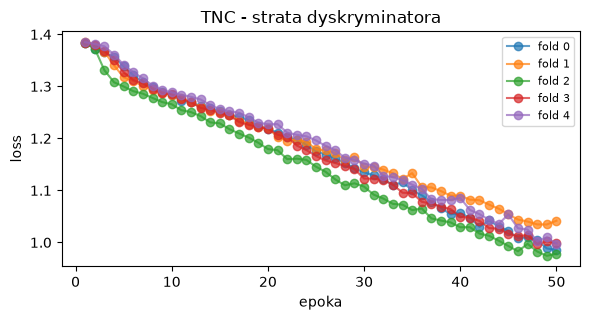

In [85]:
plot_hist(tnc_hist, 'TNC - strata dyskryminatora',None)

## 4.3. Badanie hiperparametrów

Dwa najważniejsze, specyficzne dla TNC hiperparametry badamy osobno (analogicznie do oryginalnego laboratorium TNC, gdzie badano `η`/sąsiedztwo oraz `w`). **Badanie wpływu liczymy na 3 foldach** (`HP_SPLITS`) - pokazuje *trend* i wyłania 2 najlepsze wartości każdego parametru do siatki 2×2 (sekcja 4.4).

### 4.3a. Wpływ `neighbor_range`
Promień sąsiedztwa decyduje, jak "blisko" w czasie okna uznajemy za podobne (odpowiednik `η` z publikacji). Wynik zapisywany do `results/tnc_hp.csv`.

In [86]:
tnc_hp_df = hp_study(lambda C, T, **p: TNCModel(C, T, **p),
                     'neighbor_range', [1, 3, 5, 10], {'num_samples': 5, 'w': 0.05}, 'tnc_hp.csv',
                     load_encoder=TNC_LOAD_ENCODER)
tnc_hp_df

Wczytano zapisana tabele badania HP (tnc_hp.csv).


,neighbor_range,Accuracy,ROC-AUC,ROC-AUC_std
0,1,0.5525,0.6214,0.1220
1,3,0.6191,0.6365,0.0947
2,5,0.5503,0.5400,0.1231
3,10,0.5441,0.5702,0.1039


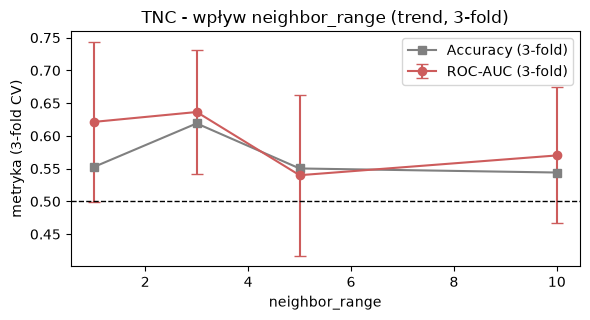

In [87]:
plt.figure(figsize=(6, 3.3))
plt.errorbar(tnc_hp_df['neighbor_range'], tnc_hp_df['ROC-AUC'], yerr=tnc_hp_df['ROC-AUC_std'],
             marker='o', color='indianred', capsize=4, label='ROC-AUC (3-fold)')
plt.plot(tnc_hp_df['neighbor_range'], tnc_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('TNC - wpływ neighbor_range (trend, 3-fold)'); plt.xlabel('neighbor_range'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

### 4.3b. Wpływ `w` (waga PU-learning)

Współczynnik `w` (Positive-Unlabeled learning) określa, w jakim stopniu okna **spoza** sąsiedztwa traktujemy jako potencjalnie pozytywne: strata negatywna to `w·BCE(·,1) + (1−w)·BCE(·,0)`. `w=0` → odległe okna są czysto negatywne; `w→1` → prawie pozytywne (model traci sygnał kontrastywny). Badamy wpływ na ROC-AUC (1 fold, trend). Wynik w `results/tnc_hp_w.csv`.

In [88]:
tnc_hp_w_df = hp_study(lambda C, T, **p: TNCModel(C, T, **p),
                       'w', [0.0, 0.05, 0.1, 0.2], {'neighbor_range': 3, 'num_samples': 5}, 'tnc_hp_w.csv',
                       load_encoder=TNC_LOAD_ENCODER)
tnc_hp_w_df

Wczytano zapisana tabele badania HP (tnc_hp_w.csv).


,w,Accuracy,ROC-AUC,ROC-AUC_std
0,0.00,0.5408,0.5674,0.1141
1,0.05,0.5912,0.6333,0.1453
2,0.10,0.5996,0.6499,0.1068
3,0.20,0.5918,0.6437,0.0694


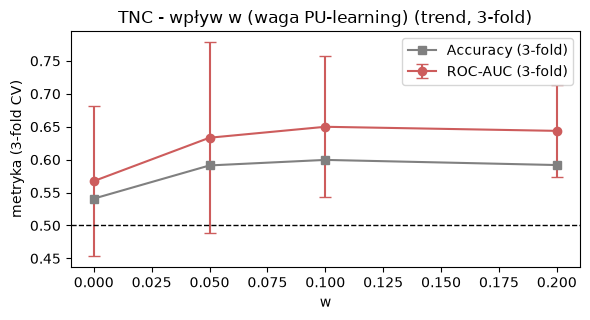

In [89]:
plt.figure(figsize=(6, 3.3))
plt.errorbar(tnc_hp_w_df['w'], tnc_hp_w_df['ROC-AUC'], yerr=tnc_hp_w_df['ROC-AUC_std'],
             marker='o', color='indianred', capsize=4, label='ROC-AUC (3-fold)')
plt.plot(tnc_hp_w_df['w'], tnc_hp_w_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('TNC - wpływ w (waga PU-learning) (trend, 3-fold)'); plt.xlabel('w'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

## 4.4. Dobór hiperparametrów - siatka 2×2

Zamiast kosztownego random search bierzemy **2 najlepsze wartości** `neighbor_range` i **2 najlepsze** `w` z badania wpływu (4.3) i sprawdzamy wszystkie **4 kombinacje** na **pełnym 5-fold CV**. Najlepszy zestaw → wariant `tnc_best`. To deterministyczne, tanie (4 konfiguracje) i opiera wybór na danych z badania HP. Wynik w `results/tnc_rs.csv`.

In [90]:
# 2 najlepsze wartosci kazdego HP z badania wplywu (4.3a neighbor_range, 4.3b w) -> siatka 2x2
tnc_grid = {'neighbor_range': top2(tnc_hp_df, 'neighbor_range'),
            'w':             top2(tnc_hp_w_df, 'w'),
            'num_samples':   [5]}   # num_samples ustalone (mniej wplywowe); siatka 2x2 po nr x w
print('=== TNC siatka 2x2 ===  neighbor_range:', tnc_grid['neighbor_range'], '| w:', tnc_grid['w'])
tnc_rs = grid_search(lambda C, T, **p: TNCModel(C, T, **p), tnc_grid, 'tnc_rs.csv',
                     load_encoder=TNC_LOAD_ENCODER)
tnc_rs

=== TNC siatka 2x2 ===  neighbor_range: [3, 1] | w: [0.1, 0.2]


Wczytano zapisana tabele siatki HP (tnc_rs.csv).


,neighbor_range,w,num_samples,Accuracy,ROC-AUC,ROC-AUC_std
0,3,0.1,5,0.6141,0.6705,0.0705
1,1,0.1,5,0.6234,0.6586,0.0991
2,1,0.2,5,0.6102,0.6389,0.1277
3,3,0.2,5,0.5884,0.6176,0.0628


### TNC z najlepszymi hiperparametrami - pełne CV
Najlepszy zestaw z siatki 2×2 dotrenowujemy na **pełnym 5-fold CV**, z **większą liczbą epok SSL** (`SSL_EPOCHS_FINAL`) - finalny model zasługuje na dłuższy trening. Wariant `tnc_best` trafia do tabeli porównawczej (sekcja 7).

In [91]:
tnc_best_params = best_params_from(tnc_rs, int_keys=('neighbor_range', 'num_samples'))
print('Najlepsze HP TNC:', tnc_best_params, f'| epoki SSL = {SSL_EPOCHS_FINAL}')
t0 = time.time()
tnc_best_acc, tnc_best_auc, tnc_best_hist = run_cv_smart(
    lambda C, T: TNCModel(C, T, **tnc_best_params),
    model_name='tnc', variant='tnc_best', ssl_epochs=SSL_EPOCHS_FINAL, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    load_encoder=TNC_LOAD_ENCODER, load_probe=TNC_LOAD_PROBE,
    hist_file='tnc_best_hist.json', res_file='tnc_best.json',
)
print(f'\nTNC (najlepszy) | Acc {fmt(tnc_best_acc)} | AUC {fmt(tnc_best_auc)}  ({time.time()-t0:.0f}s)')

Najlepsze HP TNC: {'neighbor_range': 3, 'w': 0.1, 'num_samples': 5} | epoki SSL = 40
[TNC_BEST] Wczytano zapisane wyniki linear-eval (tnc_best.json) - bez probe i treningu.

TNC (najlepszy) | Acc 0.643 ± 0.053 | AUC 0.675 ± 0.059  (0s)


## 4.5. Wyniki i wnioski - TNC

> Raportujemy dwie metryki: **per-okno** (linear-eval z tej sekcji) oraz **per-pacjent** (sekcja 7.1, metryka rozstrzygająca klinicznie). Tam, gdzie się rozjeżdżają, zaznaczamy to wprost.

**Domyślny TNC vs baseline AE.** Domyślny TNC (`neighbor_range=3, num_samples=5, w=0.05`) osiąga **per-okno AUC 0.606 ± 0.068** wobec **0.580 ± 0.111** dla autoenkodera. Przewaga jest niewielka i mieści się w przedziale odchyleń - w wariancie *domyślnym* sama strata sąsiedztwa czasowego nie daje jeszcze wyraźnego zysku nad rekonstrukcyjnym baseline'em (dopiero strojenie HP ujawnia potencjał metody - niżej). Warto odnotować, że baseline AE jest **niestabilny**: w 3 z 5 foldów degeneruje się do AUC 0.5, a wysoka średnia bierze się z 2 foldów (0.62 i 0.78) - stąd duże std ±0.111. Na poziomie **per-pacjenta** TNC daje **0.667 ± 0.117** wobec **0.612 ± 0.100** dla AE - przewaga jest, ale mieści się w przedziale odchyleń.

**Wpływ `neighbor_range`.** W badaniu wpływu (3-fold) najlepsza była wartość **3** (AUC 0.637 ± 0.095), przed `nr=1` (0.621 ± 0.122). Szersze sąsiedztwa wypadły gorzej: `nr=10` (0.570 ± 0.104) i `nr=5` (0.540 ± 0.123). Do siatki 2×2 weszły więc dwie najlepsze wartości: **3 i 1**. Interpretacja: zbyt szerokie sąsiedztwo zaczyna traktować jako pozytywne okna odległe czasowo, rozmywając sygnał kontrastywny; promień 3 to dobry kompromis dla wolnozmiennej struktury EEG.

**Wpływ `w` (waga PU-learning).** Najlepsze okazały się **`w=0.1`** (AUC 0.650 ± 0.107) i `w=0.2` (0.644 ± 0.069); domyślne `w=0.05` (0.633 ± 0.145) tuż za nimi, a `w=0.0` (twarde negatywy, 0.567 ± 0.114) najsłabiej. Potwierdza to rolę PU-learningu z oryginału: traktowanie odległych okien jako *nieoznaczonych* (a nie twardo negatywnych) pomaga. Do siatki 2×2 weszły **0.1 i 0.2**.

**Zysk z optymalizacji.** Siatka 2×2 (`neighbor_range ∈ {3,1}` × `w ∈ {0.1,0.2}`) wskazała jako najlepszy zestaw **`neighbor_range=3, w=0.1`** (AUC 0.671 ± 0.071 w siatce). Dotrenowany na pełnym 5-fold CV z `SSL_EPOCHS_FINAL` epokami daje per-okno AUC **0.675 ± 0.059** (z 0.606 domyślnego, **+0.069**).

> *Uwaga metodologiczna:* siatka 2×2 i wariant `best` korzystają z tego samego CV, na którym raportujemy wynik (brak nested CV - niepraktyczne przy 67 pacjentach), więc `best` jest lekko optymistycznie obciążony. Wysokie std (±0.06-0.13) wynika z małej liczby pacjentów na fold - różnice rzędu 0.05-0.10 AUC traktujemy jako orientacyjne, nie istotne statystycznie.


---
# 5. CPC - Contrastive Predictive Coding

## 5.1. Krótki opis
- **Publikacja:** van den Oord, Li, Vinyals, *Representation Learning with Contrastive Predictive Coding*, arXiv:1807.03748 (2018).
- **Idea:** enkoder `g_enc` koduje okno do `z_t`; autoregresor `g_ar` (**GRU**) buduje kontekst `c_t`. Dla horyzontu `k` projekcja `W_k` przewiduje `z_{t+k}`. Trening stratą **InfoNCE**.
- **Nasze adaptacje / wprowadzone zmiany:**
  1. enkoder splotowy **wspólny z TNC** (`src/models/encoder.py`, 128-d, global pooling) - patrz uwaga w 4.1;
  2. negatywy losowane wewnątrz sekwencji jednego pacjenta (in-batch negatives);
  3. **ablacja głowicy projekcyjnej (SimCLR)** - jak w TNC (4.1): sprawdzona, na tym zbiorze pogarsza wynik, więc finalnie `use_projection=False`.
  
  Implementacja modelu: `src/models/cpc.py`.

**Hiperparametry:** `prediction_steps`, `context_dim`.

## 5.2. Odpalenie dla wartości domyślnych

In [92]:
print('=== CPC (domyślne: context_dim=128, prediction_steps=4) ===')
t0 = time.time()
cpc_acc, cpc_auc, cpc_hist = run_cv_smart(
    lambda C, T: CPCModel(C, T, context_dim=128, prediction_steps=4),
    model_name='cpc', variant='cpc', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    load_encoder=CPC_LOAD_ENCODER, load_probe=CPC_LOAD_PROBE,
    hist_file='cpc_default_hist.json', res_file='cpc_default.json',
)
print(f'\nCPC (domyślny) | Acc {fmt(cpc_acc)} | AUC {fmt(cpc_auc)}  ({time.time()-t0:.0f}s)')

=== CPC (domyślne: context_dim=128, prediction_steps=4) ===
[CPC] Wczytano zapisane wyniki linear-eval (cpc_default.json) - bez probe i treningu.

CPC (domyślny) | Acc 0.631 ± 0.070 | AUC 0.681 ± 0.087  (0s)


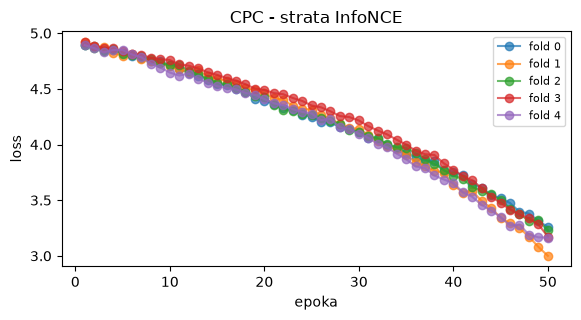

In [93]:
plot_hist(cpc_hist, 'CPC - strata InfoNCE',
          'Wczytano gotowe wyniki - brak historii treningu (ustaw CPC_LOAD_ENCODER=False, by ją zobaczyć).')

## 5.3. Badanie hiperparametrów

Dwa hiperparametry CPC badamy osobno na **3 foldach** (`HP_SPLITS`) - pokazuje trend i wyłania 2 najlepsze wartości każdego do siatki 2×2 (5.4).

### 5.3a. Wpływ `prediction_steps`
Liczba kroków predykcji w przód. Większa wartość = dłuższe zależności czasowe, ale trudniejsze zadanie. Wynik w `results/cpc_hp.csv`.

In [94]:
cpc_hp_df = hp_study(lambda C, T, **p: CPCModel(C, T, **p),
                     'prediction_steps', [1, 2, 4, 8], {'context_dim': 128}, 'cpc_hp.csv',
                     load_encoder=CPC_LOAD_ENCODER)
cpc_hp_df

Wczytano zapisana tabele badania HP (cpc_hp.csv).


,prediction_steps,Accuracy,ROC-AUC,ROC-AUC_std
0,1,0.6100,0.6696,0.1197
1,2,0.5641,0.6350,0.1013
2,4,0.6308,0.6922,0.0547
3,8,0.6075,0.6183,0.0861


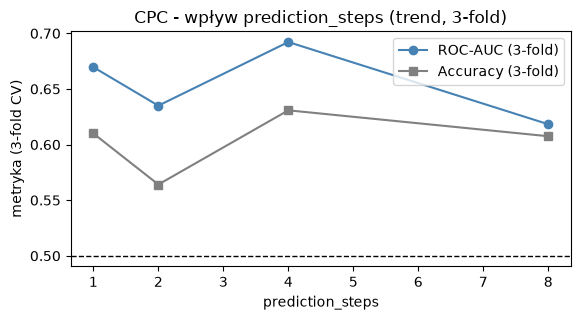

In [95]:
plt.figure(figsize=(6, 3.3))
plt.plot(cpc_hp_df['prediction_steps'], cpc_hp_df['ROC-AUC'], marker='o', color='steelblue', label='ROC-AUC (3-fold)')
plt.plot(cpc_hp_df['prediction_steps'], cpc_hp_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('CPC - wpływ prediction_steps (trend, 3-fold)'); plt.xlabel('prediction_steps'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

### 5.3b. Wpływ `context_dim`

Wymiar kontekstu autoregresora GRU (`c_t`). Większy = pojemniejszy kontekst, ale więcej parametrów i ryzyko przeuczenia na małym zbiorze. Badamy wpływ na ROC-AUC (3 foldy, trend). Wynik w `results/cpc_hp_ctx.csv`.

In [96]:
cpc_hp_ctx_df = hp_study(lambda C, T, **p: CPCModel(C, T, **p),
                         'context_dim', [32, 64, 128, 256], {'prediction_steps': 4}, 'cpc_hp_ctx.csv',
                         load_encoder=CPC_LOAD_ENCODER)
cpc_hp_ctx_df

Wczytano zapisana tabele badania HP (cpc_hp_ctx.csv).


,context_dim,Accuracy,ROC-AUC,ROC-AUC_std
0,32,0.6421,0.6808,0.1025
1,64,0.6377,0.6764,0.0729
2,128,0.5946,0.6345,0.1179
3,256,0.6656,0.6944,0.0934


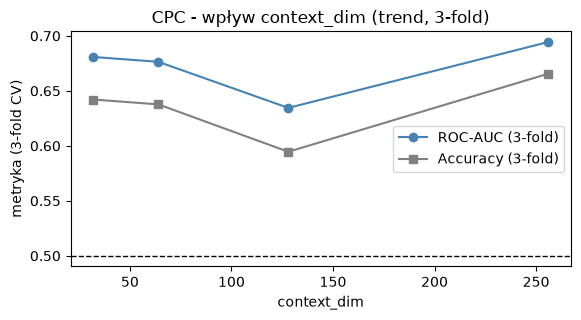

In [97]:
plt.figure(figsize=(6, 3.3))
plt.plot(cpc_hp_ctx_df['context_dim'], cpc_hp_ctx_df['ROC-AUC'], marker='o', color='steelblue', label='ROC-AUC (3-fold)')
plt.plot(cpc_hp_ctx_df['context_dim'], cpc_hp_ctx_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('CPC - wpływ context_dim (trend, 3-fold)'); plt.xlabel('context_dim'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

## 5.4. Dobór hiperparametrów - siatka 2×2

2 najlepsze `prediction_steps` (5.3a) × 2 najlepsze `context_dim` (5.3b), wszystkie **4 kombinacje** na **pełnym 5-fold CV**. Najlepszy → `cpc_best`. Wynik w `results/cpc_rs.csv`.

In [98]:
# 2 najlepsze wartosci kazdego HP z badania wplywu (5.3a prediction_steps, 5.3b context_dim) -> siatka 2x2
cpc_grid = {'prediction_steps': top2(cpc_hp_df, 'prediction_steps'),
            'context_dim':      top2(cpc_hp_ctx_df, 'context_dim')}
print('=== CPC siatka 2x2 ===  prediction_steps:', cpc_grid['prediction_steps'], '| context_dim:', cpc_grid['context_dim'])
cpc_rs = grid_search(lambda C, T, **p: CPCModel(C, T, **p), cpc_grid, 'cpc_rs.csv',
                     load_encoder=CPC_LOAD_ENCODER)
cpc_rs

=== CPC siatka 2x2 ===  prediction_steps: [4, 1] | context_dim: [256, 32]
Wczytano zapisana tabele siatki HP (cpc_rs.csv).


,prediction_steps,context_dim,Accuracy,ROC-AUC,ROC-AUC_std
0,1,32,0.6766,0.7428,0.0897
1,4,32,0.6724,0.7350,0.0938
2,4,256,0.6114,0.6684,0.0831
3,1,256,0.6206,0.6682,0.1080


### CPC z najlepszymi hiperparametrami - pełne CV
Najlepszy zestaw z siatki 2×2 dotrenowany na **pełnym 5-fold CV**, z większą liczbą epok SSL (`SSL_EPOCHS_FINAL`). Wariant `cpc_best`.

In [99]:
cpc_best_params = best_params_from(cpc_rs, int_keys=('prediction_steps', 'context_dim'))
print('Najlepsze HP CPC:', cpc_best_params, f'| epoki SSL = {SSL_EPOCHS_FINAL}')
t0 = time.time()
cpc_best_acc, cpc_best_auc, cpc_best_hist = run_cv_smart(
    lambda C, T: CPCModel(C, T, **cpc_best_params),
    model_name='cpc', variant='cpc_best', ssl_epochs=SSL_EPOCHS_FINAL, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    load_encoder=CPC_LOAD_ENCODER, load_probe=CPC_LOAD_PROBE,
    hist_file='cpc_best_hist.json', res_file='cpc_best.json',
)
print(f'\nCPC (najlepszy) | Acc {fmt(cpc_best_acc)} | AUC {fmt(cpc_best_auc)}  ({time.time()-t0:.0f}s)')

Najlepsze HP CPC: {'prediction_steps': 1, 'context_dim': 32} | epoki SSL = 40
[CPC_BEST] Wczytano zapisane wyniki linear-eval (cpc_best.json) - bez probe i treningu.

CPC (najlepszy) | Acc 0.647 ± 0.097 | AUC 0.713 ± 0.112  (0s)


## 5.5. Wyniki i wnioski - CPC

**Domyślny CPC vs baseline AE.** Domyślny CPC (`context_dim=128, prediction_steps=4`) osiąga **per-okno AUC 0.681 ± 0.087** wobec **0.580 ± 0.111** dla autoenkodera - i jest to najwyższy wynik *domyślny* spośród wszystkich metod (powyżej domyślnego TNC 0.606), a w dodatku bardziej konsekwentny niż niestabilny baseline AE (który degeneruje się do 0.5 w części foldów). Predykcja przyszłych okien (InfoNCE) wymusza cechy niosące informację o dynamice sygnału, użyteczniejsze niż czysta rekonstrukcja AE. Na poziomie **per-pacjenta** domyślny CPC daje aż **0.773 ± 0.094** - praktycznie najlepszy wynik per-pacjent wśród wariantów *domyślnych* (sekcja 7.1).

**Wpływ `prediction_steps` (horyzont predykcji).** Zależność jest **niemonotoniczna** z maksimum w środku: najlepszy **`steps=4`** (AUC 0.692 ± 0.055), tuż za nim `steps=1` (0.670 ± 0.120), słabiej `steps=2` (0.635) i `steps=8` (0.618). Zbyt długi horyzont (`8`) czyni zadanie pretekstowe za trudnym na małym zbiorze, zbyt krótki (`1`, `2`) - za łatwym; `steps=4` najlepiej balansuje. Do siatki 2×2 weszły **4 i 1**.

**Wpływ `context_dim`.** Różnice są niewielkie i nieoczywiste: najlepszy **`256`** (AUC 0.694 ± 0.093) i `32` (0.681 ± 0.103), środek słabiej - `64` (0.676) i `128` (0.635). Co ciekawe, domyślne `128` wypada tu najsłabiej; mały kontekst (`32`) okazuje się wystarczający, a duży (`256`) nie daje istotnej przewagi przy większym ryzyku przeuczenia GRU na małej próbie. Do siatki 2×2 weszły **256 i 32**.

**Zysk z optymalizacji.** Siatka 2×2 (`prediction_steps ∈ {4,1}` × `context_dim ∈ {256,32}`) wskazała najlepszy zestaw **`prediction_steps=1, context_dim=32`** (AUC 0.743 ± 0.090 w siatce). Dotrenowany na pełnym 5-fold CV (`SSL_EPOCHS_FINAL`) daje per-okno AUC **0.713 ± 0.112** (z 0.681 domyślnego, **+0.032**) - to **najwyższy per-okno AUC w całym raporcie**.

> *Uwaga metodologiczna:* jak w 4.5 - `best` dzieli CV z raportowaniem (lekkie obciążenie optymistyczne), a wysokie std (±0.09-0.13) przy 67 pacjentach każe traktować różnice rzędu 0.03-0.05 AUC jako orientacyjne. Rozjazd kierunku zmiany per-okno (+) vs per-pacjent (−) dla CPC dobrze ilustruje, dlaczego raportujemy obie metryki.


---
# 6. Mamba - model przestrzeni stanów

## 6.1. Krótki opis
- **Publikacja:** Albert Gu, Tri Dao, *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*, arXiv:2312.00752 (2024).
- **Idea:** `MambaEncoder` koduje każde okno EEG wewnętrznie - SSM przetwarza patche i akumuluje stan ukryty `h_t` wewnątrz okna, produkując reprezentację `z_t` (ostatni token). Projekcja liniowa przewiduje `z_{t+k}`. Trening stratą InfoNCE, negatywy losowane wewnątrz sekwencji pacjenta.
- **Uproszczenia względem oryginału:** jawna pętla Python po czasie zamiast równoległego CUDA kernela; 2 bloki Mamby zamiast 24-48 (mały zbiór).
- **Adaptacja pod EEG:** `_EEGPatchEmbed` tworzy 12 patchy/okno (wycinki sygnału ze wszystkich kanałów); `_pool` bierze ostatni token (zakumulowany stan SSM).

  Implementacja: `src/models/mamba_model.py`.

**Hiperparametry:** `d_model` (wymiar reprezentacji), `d_state` (pojemność pamięci SSM). Badanie wpływu na 3 foldach + siatka 2×2 na pełnym CV (spójnie z TNC/CPC).

## 6.2. Odpalenie dla wartości domyślnych

In [100]:
print('=== Mamba (domyślne: d_model=64, d_state=16) ===')
t0 = time.time()
mamba_acc, mamba_auc, mamba_hist = run_cv_smart(
    lambda C, T: MambaModel(C, T, d_model=64, d_state=16),
    model_name='mamba', variant='mamba', ssl_epochs=SSL_EPOCHS, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    load_encoder=MAMBA_LOAD_ENCODER, load_probe=MAMBA_LOAD_PROBE,
    hist_file='mamba_default_hist.json', res_file='mamba_default.json',
)
print(f'\nMamba (domyślny) | Acc {fmt(mamba_acc)} | AUC {fmt(mamba_auc)}  ({time.time()-t0:.0f}s)')

=== Mamba (domyślne: d_model=64, d_state=16) ===
[MAMBA] Wczytano zapisane wyniki linear-eval (mamba_default.json) - bez probe i treningu.

Mamba (domyślny) | Acc 0.542 ± 0.010 | AUC 0.545 ± 0.014  (0s)


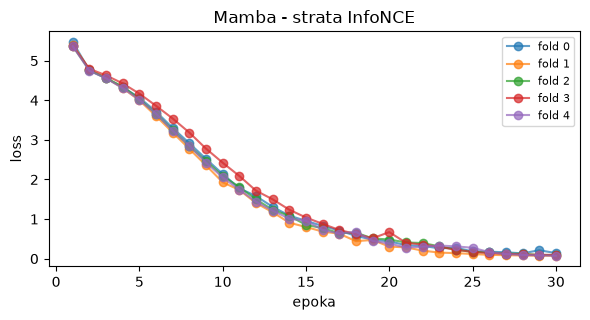

In [101]:
plot_hist(mamba_hist, 'Mamba - strata InfoNCE',
          'Wczytano gotowe wyniki - brak historii treningu (ustaw MAMBA_LOAD_ENCODER=False, by ją zobaczyć).')

## 6.3. Badanie hiperparametrów

Dwa hiperparametry Mamby badamy osobno na **3 foldach** (`HP_SPLITS`) - trend + wybór 2 najlepszych wartości do siatki 2×2 (6.4).

### 6.3a. Wpływ `d_model`
Wymiar przestrzeni reprezentacji SSM. Wynik w `results/mamba_hp_dmodel.csv`.

In [102]:
mamba_hp_dmodel_df = hp_study(lambda C, T, **p: MambaModel(C, T, **p),
                              'd_model', [32, 64, 128, 256], {'d_state': 16}, 'mamba_hp_dmodel.csv',
                              load_encoder=MAMBA_LOAD_ENCODER)
mamba_hp_dmodel_df

Wczytano zapisana tabele badania HP (mamba_hp_dmodel.csv).


,d_model,Accuracy,ROC-AUC,ROC-AUC_std
0,32,0.5234,0.5254,0.0
1,64,0.5248,0.5257,0.0
2,128,0.5315,0.5330,0.0
3,256,0.5253,0.5277,0.0


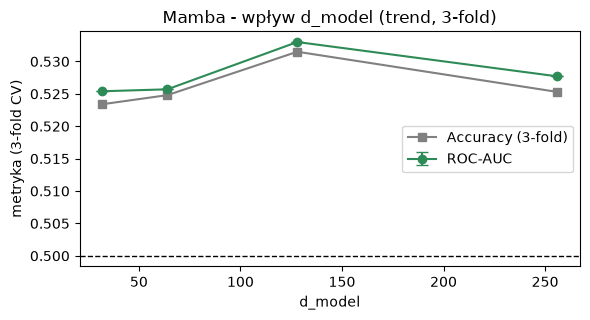

In [103]:
plt.figure(figsize=(6, 3.3))
_yerr = mamba_hp_dmodel_df['ROC-AUC_std'] if 'ROC-AUC_std' in mamba_hp_dmodel_df else None
plt.errorbar(mamba_hp_dmodel_df['d_model'], mamba_hp_dmodel_df['ROC-AUC'], yerr=_yerr,
             marker='o', color='seagreen', capsize=4, label='ROC-AUC')
plt.plot(mamba_hp_dmodel_df['d_model'], mamba_hp_dmodel_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('Mamba - wpływ d_model (trend, 3-fold)'); plt.xlabel('d_model'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

### 6.3b. Wpływ `d_state`
Pojemność pamięci stanu ukrytego SSM. Wynik w `results/mamba_hp_dstate.csv`.

In [104]:
mamba_hp_dstate_df = hp_study(lambda C, T, **p: MambaModel(C, T, **p),
                              'd_state', [8, 16, 32, 64], {'d_model': 64}, 'mamba_hp_dstate.csv',
                              load_encoder=MAMBA_LOAD_ENCODER)
mamba_hp_dstate_df

Wczytano zapisana tabele badania HP (mamba_hp_dstate.csv).


,d_state,Accuracy,ROC-AUC,ROC-AUC_std
0,8,0.5338,0.5241,0.0
1,16,0.5196,0.5252,0.0
2,32,0.5248,0.5226,0.0
3,64,0.5253,0.5221,0.0


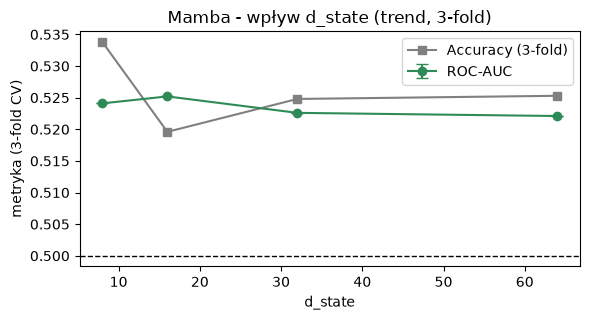

In [105]:
plt.figure(figsize=(6, 3.3))
_yerr = mamba_hp_dstate_df['ROC-AUC_std'] if 'ROC-AUC_std' in mamba_hp_dstate_df else None
plt.errorbar(mamba_hp_dstate_df['d_state'], mamba_hp_dstate_df['ROC-AUC'], yerr=_yerr,
             marker='o', color='seagreen', capsize=4, label='ROC-AUC')
plt.plot(mamba_hp_dstate_df['d_state'], mamba_hp_dstate_df['Accuracy'], marker='s', color='gray', label='Accuracy (3-fold)')
plt.axhline(0.5, ls='--', c='k', lw=1)
plt.title('Mamba - wpływ d_state (trend, 3-fold)'); plt.xlabel('d_state'); plt.ylabel('metryka (3-fold CV)')
plt.legend(); plt.tight_layout(); plt.show()

## 6.4. Dobór hiperparametrów - siatka 2×2

2 najlepsze `d_model` (6.3a) × 2 najlepsze `d_state` (6.3b), wszystkie **4 kombinacje** na **pełnym 5-fold CV**. Najlepszy → `mamba_best`. Wynik w `results/mamba_rs.csv`.

In [106]:
# 2 najlepsze wartosci kazdego HP z badania wplywu (6.3a d_model, 6.3b d_state) -> siatka 2x2
mamba_grid = {'d_model': top2(mamba_hp_dmodel_df, 'd_model'),
              'd_state': top2(mamba_hp_dstate_df, 'd_state')}
print('=== Mamba siatka 2x2 ===  d_model:', mamba_grid['d_model'], '| d_state:', mamba_grid['d_state'])
mamba_rs = grid_search(lambda C, T, **p: MambaModel(C, T, **p), mamba_grid, 'mamba_rs.csv',
                       load_encoder=MAMBA_LOAD_ENCODER)
mamba_rs

=== Mamba siatka 2x2 ===  d_model: [128, 256] | d_state: [16, 8]
Wczytano zapisana tabele siatki HP (mamba_rs.csv).


,d_model,d_state,Accuracy,ROC-AUC,ROC-AUC_std
0,128,16,0.5255,0.5291,0.0
1,128,8,0.5327,0.5286,0.0
2,256,16,0.5224,0.5264,0.0
3,256,8,0.5295,0.5259,0.0


### Mamba z najlepszymi hiperparametrami - pełne CV
Najlepszy zestaw z siatki 2×2 dotrenowany na **pełnym 5-fold CV** (`SSL_EPOCHS_FINAL`). Wariant `mamba_best`.

In [107]:
mamba_best_params = best_params_from(mamba_rs, int_keys=('d_model', 'd_state'))
print('Najlepsze HP Mamba:', mamba_best_params, f'| epoki SSL = {SSL_EPOCHS_FINAL}')
t0 = time.time()
mamba_best_acc, mamba_best_auc, mamba_best_hist = run_cv_smart(
    lambda C, T: MambaModel(C, T, **mamba_best_params),
    model_name='mamba', variant='mamba_best', ssl_epochs=SSL_EPOCHS_FINAL, n_splits=N_SPLITS, probe_epochs=PROBE_EPOCHS,
    load_encoder=MAMBA_LOAD_ENCODER, load_probe=MAMBA_LOAD_PROBE,
    hist_file='mamba_best_hist.json', res_file='mamba_best.json',
)
print(f'\nMamba (najlepszy) | Acc {fmt(mamba_best_acc)} | AUC {fmt(mamba_best_auc)}  ({time.time()-t0:.0f}s)')

Najlepsze HP Mamba: {'d_model': 128, 'd_state': 16} | epoki SSL = 40
[MAMBA_BEST] Wczytano zapisane wyniki linear-eval (mamba_best.json) - bez probe i treningu.

Mamba (najlepszy) | Acc 0.534 ± 0.011 | AUC 0.534 ± 0.014  (0s)


## 6.5. Wyniki i wnioski - Mamba

**Rozjazd metryk - kluczowa obserwacja.** Mamba zachowuje się skrajnie odmiennie w dwóch metrykach i jest najlepszą ilustracją, dlaczego raportujemy obie:

- **Per-okno** wynik jest **bliski losowego**: domyślny AUC **0.545 ± 0.014**, best **0.534 ± 0.014**, poniżej baseline'u AE (0.580 ± 0.111) i blisko poziomu losowego (0.5). Strojenie HP nic nie daje - cała siatka `d_model × d_state` mieści się w wąskim paśmie 0.52-0.53 (badanie wpływu pokazuje praktycznie płaskie krzywe).
- **Per-pacjent** Mamba ma natomiast **najwyższy AUC w całym raporcie**: domyślny **0.812 ± 0.065**, best **0.833 ± 0.101** - powyżej TNC best (0.771) i CPC (0.773). Najlepszy zestaw to `d_model=128, d_state=16`.

**Interpretacja.** Rekurencja SSM w `MambaEncoder` operuje **wyłącznie wewnątrz pojedynczego okna**: stan ukryty `h_t` akumuluje informację o 12 patchach (3 s sygnału) i jest resetowany dla każdego nowego okna. Pojedyncze okno niesie zbyt mało sygnału diagnostycznego, by liniowo rozdzielić klasy - stąd słaby AUC **per-okno**. Dopiero **agregacja po pacjencie** (uśrednienie predykcji jego kilkudziesięciu-kilkuset okien) wyławia słaby, ale **systematyczny** bias w prawdopodobieństwach: drobne, spójne przesunięcie powtarzane na wielu oknach daje wyraźny rozdział na poziomie pacjenta. Mamba uczy się więc cechy słabej per-okno, lecz zaskakująco stabilnej po uśrednieniu.

**Uwaga ostrożnościowa.** Wysoki per-pacjent AUC Mamby idzie w parze z **niespójnymi metrykami progowymi**: Acc 0.521-0.565 (na poziomie losowym) i Recall(AD) 0.51-0.57 z **bardzo dużym std (±0.45-0.47)** - w części foldów F1/Precision/Recall spadają do 0. Oznacza to, że choć *ranking* prawdopodobieństw rozdziela klasy (wysokie AUC), to *kalibracja progu* 0.5 jest niestabilna między foldami. Przy 67 pacjentach (≈13/fold) AUC per-pacjent ma duży rozrzut i część tego wyniku może być artefaktem małej próby. Per-okno AUC ~0.54 trzeba więc czytać jako sygnał, że surowa reprezentacja Mamby jest słaba; per-pacjent 0.83 - jako obiecujący, lecz ostrożnie interpretowany efekt agregacji, wymagający większego zbioru do potwierdzenia.


---
# 7. Podsumowanie zbiorcze

Tabela i wykres zestawiające metody w wariancie **domyślnym i najlepszym** (po optymalizacji hiperparametrów). Wymagana przez specyfikację tabela głównego eksperymentu z porównaniem do naiwnego baseline'u.

In [108]:
summary = pd.DataFrame([
    {'Model': 'Baseline (AE)', 'Acc (domyślny)': fmt(ae_acc), 'AUC (domyślny)': fmt(ae_auc),
     'Acc (najlepszy)': '-', 'AUC (najlepszy)': '-', '_auc': np.mean(ae_auc)},
    {'Model': 'TNC', 'Acc (domyślny)': fmt(tnc_acc), 'AUC (domyślny)': fmt(tnc_auc),
     'Acc (najlepszy)': fmt(tnc_best_acc), 'AUC (najlepszy)': fmt(tnc_best_auc), '_auc': np.mean(tnc_best_auc)},
    {'Model': 'CPC', 'Acc (domyślny)': fmt(cpc_acc), 'AUC (domyślny)': fmt(cpc_auc),
     'Acc (najlepszy)': fmt(cpc_best_acc), 'AUC (najlepszy)': fmt(cpc_best_auc), '_auc': np.mean(cpc_best_auc)},
    {'Model': 'Mamba', 'Acc (domyślny)': fmt(mamba_acc), 'AUC (domyślny)': fmt(mamba_auc),
     'Acc (najlepszy)': fmt(mamba_best_acc), 'AUC (najlepszy)': fmt(mamba_best_auc), '_auc': np.mean(mamba_best_auc)},
]).sort_values('_auc', ascending=False).drop(columns='_auc').reset_index(drop=True)
print('Tabela główna - klasyfikacja liniowa, AUC/Acc (średnia ± std po CV):')
print('("najlepszy" = po optymalizacji hiperparametrów siatką 2×2 na pełnym CV)')
summary

Tabela główna - klasyfikacja liniowa, AUC/Acc (średnia ± std po CV):
("najlepszy" = po optymalizacji hiperparametrów siatką 2×2 na pełnym CV)


,Model,Acc (domyślny),AUC (domyślny),Acc (najlepszy),AUC (najlepszy)
0,CPC,0.631 ± 0.070,0.681 ± 0.087,0.647 ± 0.097,0.713 ± 0.112
1,TNC,0.612 ± 0.034,0.606 ± 0.068,0.643 ± 0.053,0.675 ± 0.059
2,Baseline (AE),0.594 ± 0.087,0.580 ± 0.111,-,-
3,Mamba,0.542 ± 0.010,0.545 ± 0.014,0.534 ± 0.011,0.534 ± 0.014


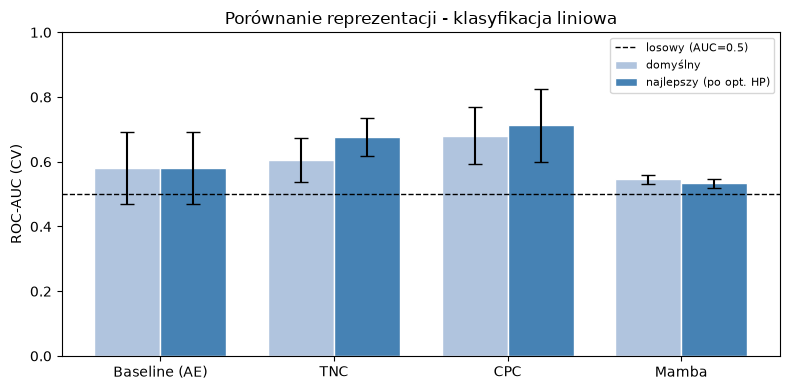

In [109]:
names    = ['Baseline (AE)', 'TNC', 'CPC', 'Mamba']
auc_def  = [np.mean(ae_auc), np.mean(tnc_auc), np.mean(cpc_auc), np.mean(mamba_auc)]
std_def  = [np.std(ae_auc),  np.std(tnc_auc),  np.std(cpc_auc),  np.std(mamba_auc)]
auc_best = [np.mean(ae_auc), np.mean(tnc_best_auc), np.mean(cpc_best_auc), np.mean(mamba_best_auc)]
std_best = [np.std(ae_auc),  np.std(tnc_best_auc),  np.std(cpc_best_auc),  np.std(mamba_best_auc)]
x = np.arange(len(names)); w = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, auc_def,  w, yerr=std_def,  capsize=5, label='domyślny', color='lightsteelblue', edgecolor='white')
plt.bar(x + w/2, auc_best, w, yerr=std_best, capsize=5, label='najlepszy (po opt. HP)', color='steelblue', edgecolor='white')
plt.axhline(0.5, ls='--', c='k', lw=1, label='losowy (AUC=0.5)')
plt.xticks(x, names)
plt.ylabel('ROC-AUC (CV)'); plt.ylim(0, 1)
plt.title('Porównanie reprezentacji - klasyfikacja liniowa')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7.1. Ewaluacja per-pacjent (agregacja okien)

Dotąd AUC liczyliśmy **per okno**. Ale diagnoza dotyczy **pacjenta**, a jeden pacjent ma 47–225 okien (które **nie są** niezależnymi próbkami). Bardziej poprawna metodologicznie i klinicznie ocena: agregujemy predykcje okien danego pacjenta (**średnie prawdopodobieństwo**) do jednej predykcji na pacjenta, a AUC liczymy na poziomie pacjentów.

In [110]:
# Ewaluacja per-pacjent: logika (trening/inference glowicy 'pat', early-stopping, cache)
# jest w src/evaluation/per_patient.py. Tu tylko zbieramy wyniki do dwoch tabel.
# Per-OKNO bierzemy GOTOWE z sekcji 4/5/6 (PERWIN_FILE); per-PACJENT liczy eval_per_patient.
# Flaga *_LOAD_PROBE danego modelu decyduje: wczytaj cache/glowice vs dotrenuj glowice 'pat'.
_PP_LOAD_PROBE = {'ae': AE_LOAD_PROBE,
                  'tnc': TNC_LOAD_PROBE, 'tnc_best': TNC_LOAD_PROBE,
                  'cpc': CPC_LOAD_PROBE, 'cpc_best': CPC_LOAD_PROBE,
                  'mamba': MAMBA_LOAD_PROBE, 'mamba_best': MAMBA_LOAD_PROBE}

_PP_VARIANTS = [('Baseline (AE)', 'ae', 'ae'),
                ('TNC',          'tnc', 'tnc'),
                ('TNC best',     'tnc_best', 'tnc'),
                ('CPC',          'cpc', 'cpc'),
                ('CPC best',     'cpc_best', 'cpc'),
                ('Mamba',        'mamba', 'mamba'),
                ('Mamba best',   'mamba_best', 'mamba')]

win_rows, pat_rows = [], []
for name, variant, model in _PP_VARIANTS:
    print(f'=== per-patient: {name} ===')
    w = load_json(RESULTS_DIR, PERWIN_FILE[variant])
    r = eval_per_patient(variant, model, load_probe=_PP_LOAD_PROBE[variant], res_file=f'perpat_{variant}.json')
    pat_rows.append({'Model': name, 'AUC': fmt(r['pat_auc']), 'Acc': fmt(r['pat_acc']),
                     'F1 (AD)': fmt(r['pat_f1']), 'Precision (AD)': fmt(r['pat_prec']),
                     'Recall/czułość (AD)': fmt(r['pat_rec']), '_auc': np.mean(r['pat_auc'])})

perpat_df = pd.DataFrame(pat_rows).sort_values('_auc', ascending=False).drop(columns='_auc').reset_index(drop=True)
print('\nTabela PER-PACJENT:')
print('     (Recall = czułość: jaki odsetek chorych AD wykryto - kluczowe w diagnozie. Metryka rozstrzygająca.)')
display(perpat_df)


=== per-patient: Baseline (AE) ===
[ae] Wczytano zapisany per-patient (perpat_ae.json).
=== per-patient: TNC ===
[tnc] Wczytano zapisany per-patient (perpat_tnc.json).
=== per-patient: TNC best ===
[tnc_best] Wczytano zapisany per-patient (perpat_tnc_best.json).
=== per-patient: CPC ===
[cpc] Wczytano zapisany per-patient (perpat_cpc.json).
=== per-patient: CPC best ===
[cpc_best] Wczytano zapisany per-patient (perpat_cpc_best.json).
=== per-patient: Mamba ===
[mamba] Wczytano zapisany per-patient (perpat_mamba.json).
=== per-patient: Mamba best ===
[mamba_best] Wczytano zapisany per-patient (perpat_mamba_best.json).

Tabela PER-PACJENT:
     (Recall = czułość: jaki odsetek chorych AD wykryto - kluczowe w diagnozie. Metryka rozstrzygająca.)


,Model,AUC,Acc,F1 (AD),Precision (AD),Recall/czułość (AD)
0,Mamba best,0.833 ± 0.101,0.565 ± 0.124,0.426 ± 0.349,0.417 ± 0.380,0.514 ± 0.448
1,Mamba,0.812 ± 0.065,0.521 ± 0.050,0.413 ± 0.338,0.324 ± 0.265,0.571 ± 0.469
2,CPC,0.773 ± 0.094,0.715 ± 0.112,0.718 ± 0.122,0.761 ± 0.154,0.714 ± 0.181
3,TNC best,0.771 ± 0.132,0.656 ± 0.132,0.615 ± 0.168,0.723 ± 0.156,0.571 ± 0.239
4,CPC best,0.741 ± 0.108,0.626 ± 0.137,0.610 ± 0.160,0.638 ± 0.097,0.600 ± 0.229
5,TNC,0.667 ± 0.117,0.565 ± 0.070,0.435 ± 0.131,0.717 ± 0.163,0.343 ± 0.146
6,Baseline (AE),0.612 ± 0.100,0.508 ± 0.029,0.413 ± 0.338,0.315 ± 0.258,0.600 ± 0.490


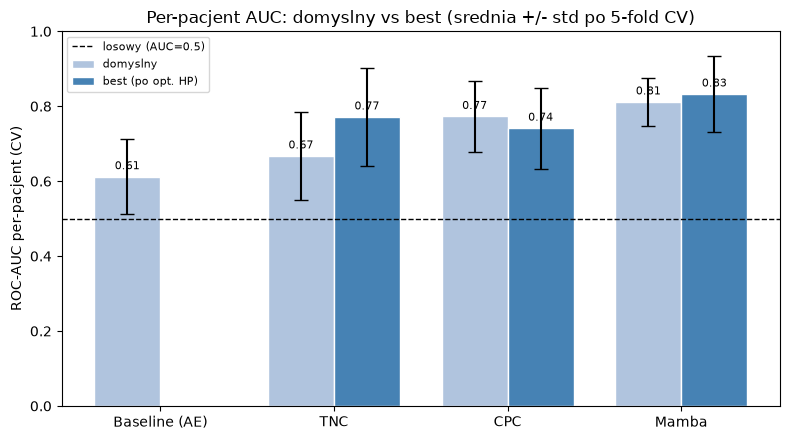

In [111]:
# Wykres slupkowy: per-pacjent AUC, domyslny vs best dla kazdej metody (errorbar = std po foldach).
# Czyta gotowe perpat_*.json (bez treningu). AE = baseline (tylko domyslny).
def _pat_auc(variant):
    d = load_json(RESULTS_DIR, f'perpat_{variant}.json')['pat_auc']
    return np.mean(d), np.std(d)

_models = [('Baseline (AE)', 'ae', None),
           ('TNC', 'tnc', 'tnc_best'),
           ('CPC', 'cpc', 'cpc_best'),
           ('Mamba', 'mamba', 'mamba_best')]
labels = [m[0] for m in _models]
def_mean, def_std, best_mean, best_std = [], [], [], []
for _, dv, bv in _models:
    m, s = _pat_auc(dv)
    def_mean.append(m)
    def_std.append(s)
    if bv is not None:
        m, s = _pat_auc(bv)
        best_mean.append(m)
        best_std.append(s)
    else:
        best_mean.append(np.nan)
        best_std.append(0.0)

x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(8, 4.5))
plt.bar(x - w/2, def_mean,  w, yerr=def_std,  capsize=5, label='domyslny',
        color='lightsteelblue', edgecolor='white')
plt.bar(x + w/2, best_mean, w, yerr=best_std, capsize=5, label='best (po opt. HP)',
        color='steelblue', edgecolor='white')
plt.axhline(0.5, ls='--', c='k', lw=1, label='losowy (AUC=0.5)')
for xi, (dm, bm) in enumerate(zip(def_mean, best_mean)):
    plt.text(xi - w/2, dm + 0.02, f'{dm:.2f}', ha='center', fontsize=8)
    if not np.isnan(bm):
        plt.text(xi + w/2, bm + 0.02, f'{bm:.2f}', ha='center', fontsize=8)
plt.xticks(x, labels)
plt.ylabel('ROC-AUC per-pacjent (CV)')
plt.ylim(0, 1)
plt.title('Per-pacjent AUC: domyslny vs best (srednia +/- std po 5-fold CV)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7.2. Wizualizacja jakosci reprezentacji

e:\Realny dysk\II_stopien\1_sem\Uczenie_Reprezentacji\Laby\Alzheimer-classifier\src\data\dataloaders.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load

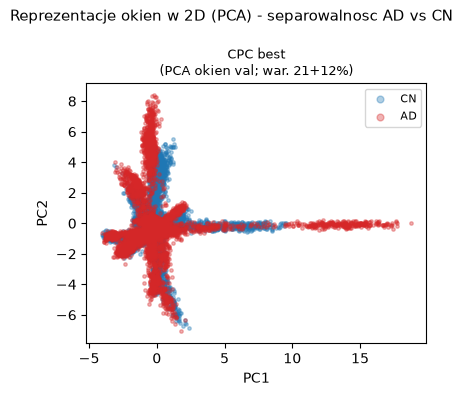

In [77]:
_VIZ_VARIANTS = [('CPC best', 'cpc_best', 'cpc')]
plot_pca(_VIZ_VARIANTS); 
plt.show()